<a href="https://colab.research.google.com/github/g11nny/medifind_project/blob/main/catdog_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!unzip -q archive.zip -d data

In [2]:
import os
for root, dirs, files in os.walk("data"):
    print(root, "| folders:", len(dirs), "| files:", len(files))
    if root.count(os.sep) >= 3:
        dirs.clear()

data | folders: 2 | files: 0
data/test | folders: 2 | files: 0
data/test/dogs | folders: 0 | files: 70
data/test/cats | folders: 0 | files: 70
data/train | folders: 2 | files: 0
data/train/dogs | folders: 0 | files: 278
data/train/cats | folders: 0 | files: 279


In [3]:
import tensorflow as tf

train = tf.keras.utils.image_dataset_from_directory(
    "data/train", image_size=(224, 224), batch_size=32)

test = tf.keras.utils.image_dataset_from_directory(
    "data/test", image_size=(224, 224), batch_size=32, shuffle=False)

print(train.class_names)

Found 557 files belonging to 2 classes.
Found 140 files belonging to 2 classes.
['cats', 'dogs']


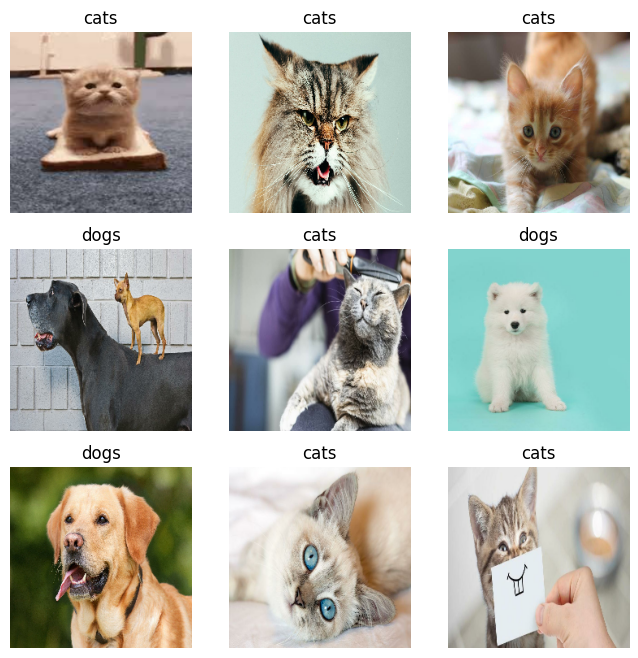

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
for images, labels in train.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train.class_names[labels[i]])
        plt.axis("off")


In [8]:
from tensorflow.keras import layers, models

base = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = layers.Rescaling(1./127.5, offset=-1)(inputs)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [9]:
history = model.fit(train, epochs=5)

Epoch 1/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 23s 817ms/step - accuracy: 0.7594 - loss: 0.5030
Epoch 2/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.9479 - loss: 0.2184
Epoch 3/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.9587 - loss: 0.1563 
Epoch 4/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.9587 - loss: 0.1198 
Epoch 5/5
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.9785 - loss: 0.0961


In [10]:
loss, acc = model.evaluate(test)
print("test accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 3s/step - accuracy: 0.9357 - loss: 0.1647
test accuracy: 0.9357143044471741


In [13]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("11.png", target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

p = float(model.predict(x)[0][0])
if p > 0.8:
    print("dog", round(p * 100, 1), "%")
elif p < 0.2:
    print("cat", round((1 - p) * 100, 1), "%")
else:
    print("not sure, maybe neither. dog score:", round(p * 100, 1), "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
not sure, maybe neither. dog score: 53.9 %


In [14]:
!pip install -q gradio

In [15]:
import gradio as gr
import numpy as np

def predict(img):
    img = img.convert("RGB").resize((224, 224))
    x = np.expand_dims(np.array(img, dtype="float32"), axis=0)
    p = float(model.predict(x, verbose=0)[0][0])

    if p > 0.8:
        verdict = "It's a dog"
    elif p < 0.2:
        verdict = "It's a cat"
    else:
        verdict = "Not sure, maybe neither"

    return {"cat": 1 - p, "dog": p}, verdict

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload a photo"),
    outputs=[gr.Label(label="Scores"), gr.Textbox(label="Answer")],
    title="Cat or Dog?",
    description="Upload a photo and the model guesses what it is.")

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b4d38601f8124693a1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
